In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load dataset
df = pd.read_csv("/content/academic Stress level - maintainance 1.csv")

In [3]:
df.head()

,Timestamp,Your Academic Stage,Peer pressure,Academic pressure from your home,Study Environment,What coping strategy you use as a student?,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life,Rate your academic stress index
0,24/07/2025 22:05:39,undergraduate,4,5,Noisy,Analyze the situation and handle it with intel...,No,3,5
1,24/07/2025 22:05:52,undergraduate,3,4,Peaceful,Analyze the situation and handle it with intel...,No,3,3
2,24/07/2025 22:06:39,undergraduate,1,1,Peaceful,"Social support (friends, family)",No,2,4
3,24/07/2025 22:06:45,undergraduate,3,2,Peaceful,Analyze the situation and handle it with intel...,No,4,3
4,24/07/2025 22:08:06,undergraduate,3,3,Peaceful,Analyze the situation and handle it with intel...,No,4,5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 9 columns):
 #   Column                                                               Non-Null Count  Dtype 
---  ------                                                               --------------  ----- 
 0   Timestamp                                                            140 non-null    object
 1   Your Academic Stage                                                  140 non-null    object
 2   Peer pressure                                                        140 non-null    int64 
 3   Academic pressure from your home                                     140 non-null    int64 
 4   Study Environment                                                    139 non-null    object
 5   What coping strategy you use as a student?                           140 non-null    object
 6   Do you have any bad habits like smoking, drinking on a daily basis?  140 non-null    object
 7   What would you rat

In [5]:
df.isnull().sum()

,0
Timestamp,0
Your Academic Stage,0
Peer pressure,0
Academic pressure from your home,0
Study Environment,1
What coping strategy you use as a student?,0
"Do you have any bad habits like smoking, drinking on a daily basis?",0
What would you rate the academic competition in your student life,0
Rate your academic stress index,0


In [6]:
df = df.dropna()

In [7]:
df.isnull().sum()

,0
Timestamp,0
Your Academic Stage,0
Peer pressure,0
Academic pressure from your home,0
Study Environment,0
What coping strategy you use as a student?,0
"Do you have any bad habits like smoking, drinking on a daily basis?",0
What would you rate the academic competition in your student life,0
Rate your academic stress index,0


In [8]:
df.describe()

,Peer pressure,Academic pressure from your home,What would you rate the academic competition in your student life,Rate your academic stress index
count,139.000000,139.000000,139.000000,139.000000
mean,3.057554,3.165468,3.482014,3.719424
std,1.075213,1.271751,1.024005,1.035800
min,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,3.000000,3.000000
50%,3.000000,3.000000,4.000000,4.000000
75%,4.000000,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000


In [9]:
df = df.drop("Timestamp", axis=1)

In [10]:
duplicates = df.duplicated().sum()
print(duplicates)

8


In [11]:
df = df.drop_duplicates()

In [12]:
#Display the unique values for all the columns

for col in df.columns:
    print(f"{col}: {df[col].unique()}\n")

Your Academic Stage: ['undergraduate' 'high school' 'post-graduate']

Peer pressure: [4 3 1 5 2]

Academic pressure from your home: [5 4 1 2 3]

Study Environment: ['Noisy' 'Peaceful' 'disrupted']

What coping strategy you use as a student?: ['Analyze the situation and handle it with intellect'
 'Social support (friends, family)' 'Emotional breakdown (crying a lot)']

Do you have any bad habits like smoking, drinking on a daily basis?: ['No' 'prefer not to say' 'Yes']

What would you rate the academic  competition in your student life: [3 2 4 5 1]

Rate your academic stress index : [5 3 4 2 1]



In [13]:
#Convert all values to lower case and remove extra spaces
df.columns = df.columns.str.lower().str.strip()

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.lower().str.strip()

In [14]:
""" Display the unique values for all the columns to confirm that extra spaces
have been removed and that upper cases have been converted to lower cases """
for col in df.columns:
    print(f"{col}: {df[col].unique()}\n")

your academic stage: ['undergraduate' 'high school' 'post-graduate']

peer pressure: [4 3 1 5 2]

academic pressure from your home: [5 4 1 2 3]

study environment: ['noisy' 'peaceful' 'disrupted']

what coping strategy you use as a student?: ['analyze the situation and handle it with intellect'
 'social support (friends, family)' 'emotional breakdown (crying a lot)']

do you have any bad habits like smoking, drinking on a daily basis?: ['no' 'prefer not to say' 'yes']

what would you rate the academic  competition in your student life: [3 2 4 5 1]

rate your academic stress index: [5 3 4 2 1]



In [15]:
# Count the number of participants that entered "prefer not to say"
count_prefer_not = (df["do you have any bad habits like smoking, drinking on a daily basis?"]
                    == "prefer not to say").sum()
print(count_prefer_not)

7


In [16]:
# Delete all rows with "prefer not to so"
df = df[df["do you have any bad habits like smoking, drinking on a daily basis?"
] != "prefer not to say"]

In [17]:
df = df.rename(columns={
    "your academic stage": "study_level",
    "academic pressure from your home": "family_pressure",
    "what coping strategy you use as a student?": "coping_strategy",
    "what would you rate the academic  competition in your student life": "academic_competition",
    "rate your academic stress index": "academic_stress_score",
    "do you have any bad habits like smoking, drinking on a daily basis?": "bad_habits"
})


In [18]:
# Apply binary encoding to bad_habits using the replace method in pandas
mapping = {
    "no": 0,
    "yes": 2
}

df["bad_habits"] = df["bad_habits"].replace(mapping)


/tmp/ipython-input-1985074980.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["bad_habits"] = df["bad_habits"].replace(mapping)


In [19]:
# Apply label encoding to bad_habits using the replace method in pandas
mapping = {
    "high school": 0,
    "undergraduate": 1,
    "post-graduate": 2
}

df["study_level"] = df["study_level"].replace(mapping)

/tmp/ipython-input-3504286423.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["study_level"] = df["study_level"].replace(mapping)


In [20]:
# Apply label encoding to study environment using the replace method in pandas
mapping = {
    "disrupted": 0,
    "noisy": 1,
    "peaceful": 2
}

df["study environment"] = df["study environment"].replace(mapping)


/tmp/ipython-input-2129545310.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["study environment"] = df["study environment"].replace(mapping)


In [21]:
# Apply label encoding to coping_strategy using the replace method in pandas
mapping = {
    "emotional breakdown (crying a lot)": 0,
    "social support (friends, family)": 1,
    "analyze the situation and handle it with intellect": 2
}

df["coping_strategy"] = df["coping_strategy"].replace(mapping)

/tmp/ipython-input-4149349550.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["coping_strategy"] = df["coping_strategy"].replace(mapping)


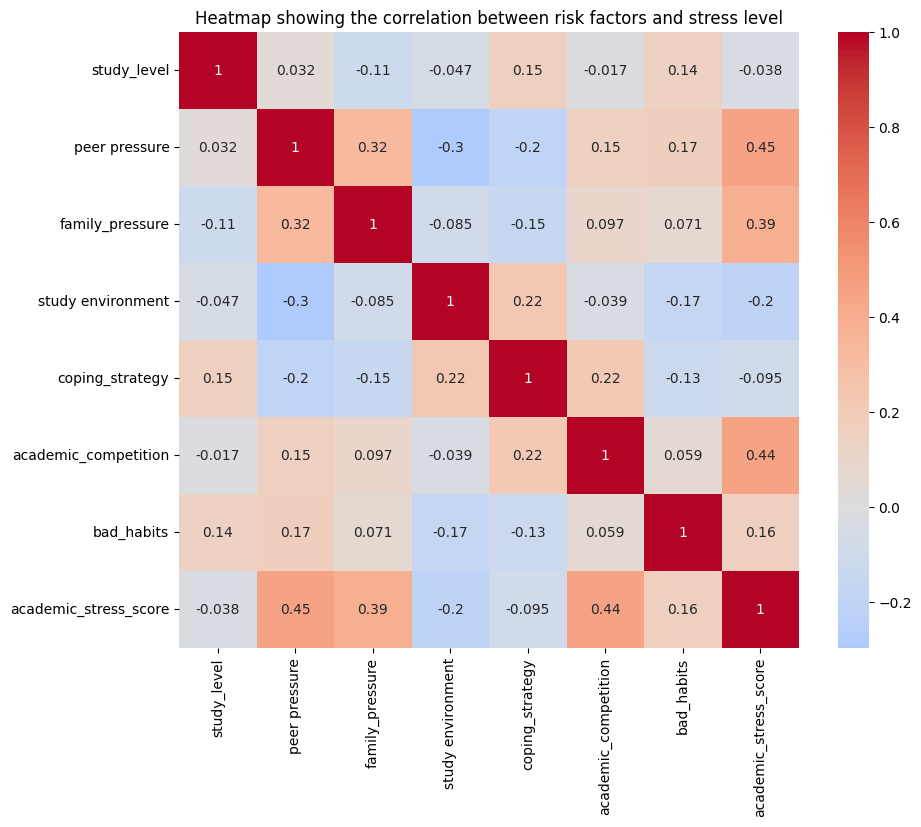

In [22]:
# Compute correlation between drug usage columns and show using a heatmap
factors = ["study_level", "peer pressure", "family_pressure",
           "study environment", "coping_strategy", "academic_competition",
           "bad_habits", "academic_stress_score"]

corr_matrix = df[factors].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Heatmap showing the correlation between risk factors and stress level")
plt.show()

In [23]:
# Linear Regression model to predict academic_stress_score from student-related factors
X = df.drop(columns=["academic_stress_score"])
y = df["academic_stress_score"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)
# Initialize model
model = LinearRegression()

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Squared Error: 0.9517013656135772
Root Mean Squared Error: 0.9755518262058542
R² Score: 0.2885007733152084
